<a href="https://colab.research.google.com/github/swathiV-17/Mobile-Sales-Forecasting/blob/main/Smart_Manufacturing_Analytics_with_Quality_Prediction_and_Process_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#imports libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)


In [2]:
# Load dataset
df = pd.read_csv("/content/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape


(10000, 14)

In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df['Machine failure'].value_counts()


,count
Machine failure,
0,9661
1,339


In [6]:
df.dtypes


,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


In [7]:
df.isnull().sum()


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
# Feature selection
# input sensor features
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
# target column
target = 'Machine failure'


In [10]:
# Outlier check using IQR
for col in features:
    Q1 = df[col].quantile(0.25)   # first quartile
    Q3 = df[col].quantile(0.75)   # third quartile
    IQR = Q3 - Q1                 # interquartile range

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # count values outside IQR limits
    outliers_count = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]

    print(f"{col}: {outliers_count} outliers")

Air temperature [K]: 0 outliers
Process temperature [K]: 0 outliers
Rotational speed [rpm]: 418 outliers
Torque [Nm]: 69 outliers
Tool wear [min]: 0 outliers


In [11]:
# Feature scaling
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

df[features].head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


In [12]:
# Train-test split
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 5)
X_test: (2000, 5)
y_train: (8000,)
y_test: (2000,)


In [13]:
# Synthetic columns for analysis
np.random.seed(40)
df_synthetic = df.copy()

# machine identifier
df_synthetic['MachineID'] = np.random.choice(
    ['M1', 'M2', 'M3', 'M4', 'M5'],
    size=len(df_synthetic)
)

# shift information
df_synthetic['Shift'] = np.random.choice(
    ['Morning', 'Afternoon', 'Night'],
    size=len(df_synthetic)
)

# timestamp column
df_synthetic['Timestamp'] = pd.date_range(
    start='2024-01-01',
    periods=len(df_synthetic),
    freq='h'
)

df_synthetic.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,MachineID,Shift,Timestamp
0,1,M14860,M,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,0,0,0,0,0,M4,Morning,2024-01-01 00:00:00
1,2,L47181,L,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,0,0,0,0,0,M1,Afternoon,2024-01-01 01:00:00
2,3,L47182,L,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,0,0,0,0,0,M1,Morning,2024-01-01 02:00:00
3,4,L47183,L,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,0,0,0,0,0,M3,Afternoon,2024-01-01 03:00:00
4,5,L47184,L,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,0,0,0,0,0,M2,Afternoon,2024-01-01 04:00:00


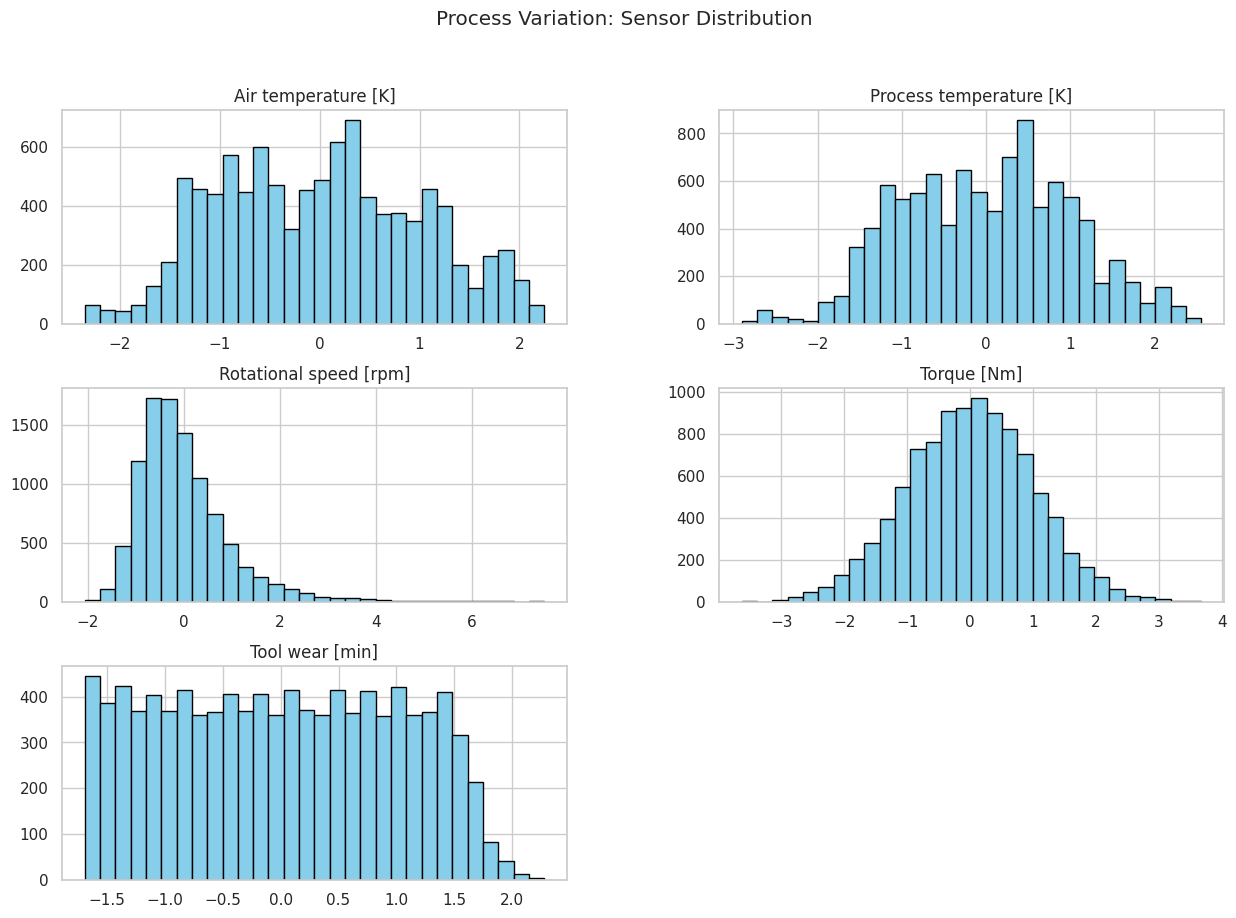

In [14]:
# Visualization
sns.set_theme(style="whitegrid")

sensors = features

df_synthetic[sensors].hist(bins=30,figsize=(15, 10),color='skyblue',edgecolor='black')
plt.suptitle('Process Variation: Sensor Distribution')
plt.show()

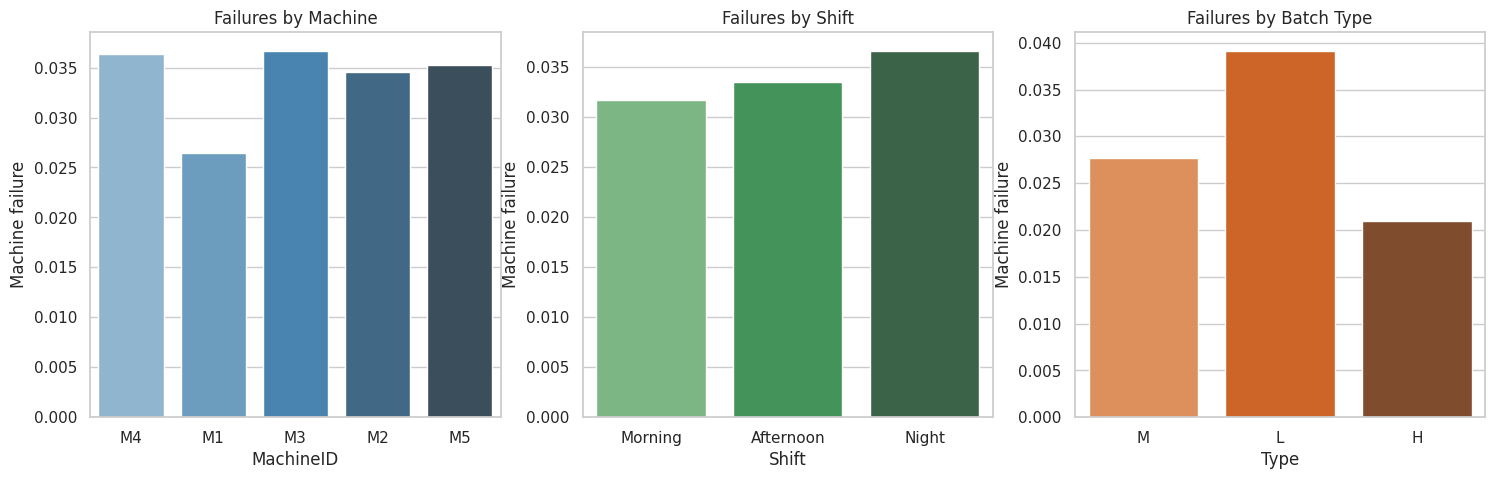

In [15]:
# failures by machine, shift and type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(ax=axes[0],x='MachineID',y='Machine failure',data=df_synthetic,hue='MachineID',palette='Blues_d',errorbar=None,legend=False)
axes[0].set_title('Failures by Machine')

sns.barplot(ax=axes[1],x='Shift',y='Machine failure',data=df_synthetic,hue='Shift',palette='Greens_d',errorbar=None,legend=False)
axes[1].set_title('Failures by Shift')

sns.barplot(ax=axes[2],x='Type',y='Machine failure',data=df_synthetic,hue='Type',palette='Oranges_d',errorbar=None,legend=False)
axes[2].set_title('Failures by Batch Type')

plt.show()

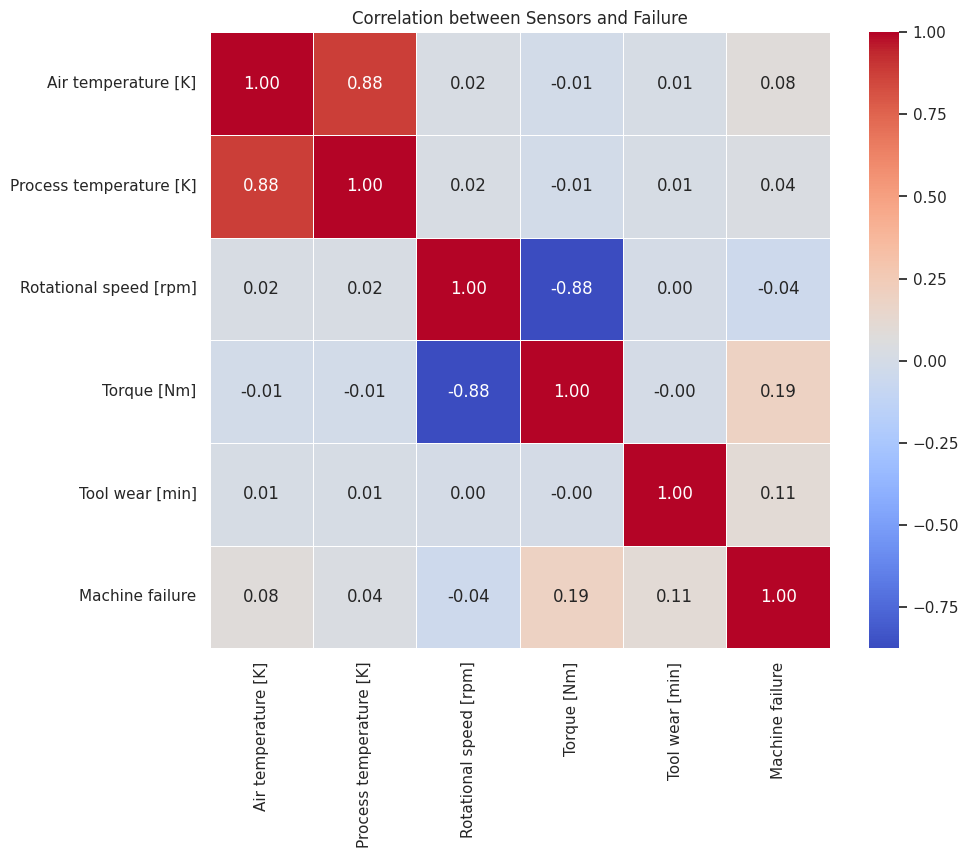

In [16]:
# Correlation analysis
numeric_cols = sensors + ['Machine failure']
correlation_matrix = df_synthetic[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Correlation between Sensors and Failure')
plt.show()

In [17]:
# Model training

# logistic regression (baseline)
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log*100:.2f}%")

# random forest (main model)
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf*100:.2f}%")

Logistic Regression Accuracy: 97.30%
Random Forest Accuracy: 98.35%


Important Sensors for Machine Failure:
Torque [Nm]: 0.3210
Rotational speed [rpm]: 0.2147
Air temperature [K]: 0.1616
Tool wear [min]: 0.1539
Process temperature [K]: 0.1488


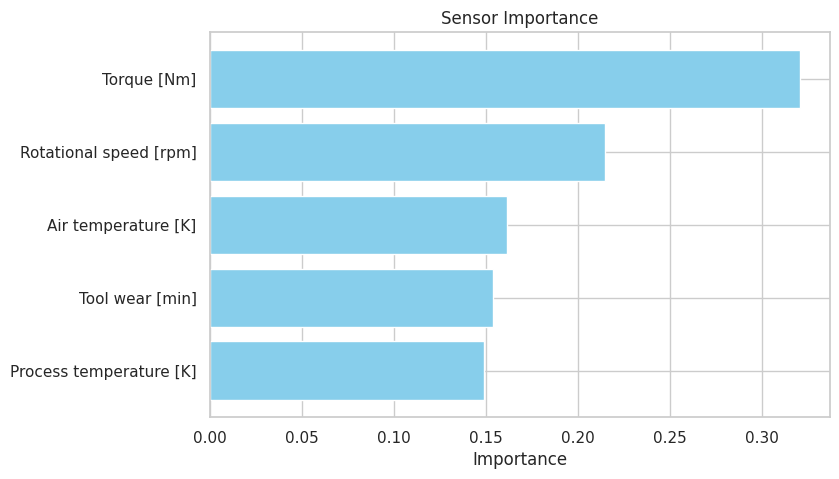

In [18]:
# Feature importance
importance_list = sorted(
    zip(features, rf_model.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)

print("Important Sensors for Machine Failure:")
for sensor, score in importance_list:
    print(f"{sensor}: {score:.4f}")

plt.figure(figsize=(8, 5))
sensors_sorted = [s for s, _ in importance_list]
scores_sorted = [s for _, s in importance_list]

plt.barh(sensors_sorted, scores_sorted, color='skyblue')
plt.xlabel('Importance')
plt.title('Sensor Importance')
plt.gca().invert_yaxis()
plt.show()

In [19]:
# Prediction results
final_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Category": y_pred_rf,
    "Defect_Probability": rf_probs
})

print("\nSample Predictions:")
for i in range(5):
    status = "DEFECT" if final_results['Predicted_Category'][i] == 1 else "NO DEFECT"
    print(
        f"Machine {i+1}: "
        f"Probability = {final_results['Defect_Probability'][i]*100:.1f}%, "
        f"Prediction = {status}"
    )

num_defects = sum(final_results['Predicted_Category'] == 1)
print(f"\nPredicted Defects: {num_defects} out of {len(final_results)}")
print(
    f"Average Defect Probability: "
    f"{final_results['Defect_Probability'].mean()*100:.1f}%")


Sample Predictions:
Machine 1: Probability = 0.0%, Prediction = NO DEFECT
Machine 2: Probability = 0.0%, Prediction = NO DEFECT
Machine 3: Probability = 0.0%, Prediction = NO DEFECT
Machine 4: Probability = 0.0%, Prediction = NO DEFECT
Machine 5: Probability = 0.0%, Prediction = NO DEFECT

Predicted Defects: 44 out of 2000
Average Defect Probability: 3.1%


In [20]:
# Model evaluation
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Model Evaluation Metrics:")
print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")

Model Evaluation Metrics:
Accuracy : 0.984
Precision: 0.818
Recall   : 0.590
F1-Score : 0.686


In [24]:
# Process optimization
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance (Process Optimization):")
print(feature_importance)
# used for tableau visualization
feature_importance.to_csv("feature_importance.csv", index=False)



Feature Importance (Process Optimization):
                   Feature  Importance
3              Torque [Nm]    0.320955
2   Rotational speed [rpm]    0.214712
0      Air temperature [K]    0.161565
4          Tool wear [min]    0.153936
1  Process temperature [K]    0.148831


In [22]:
# Risk-based alerting
alert_threshold = 0.7

high_risk_machines = final_results[
    final_results['Defect_Probability'] > alert_threshold
]

print("Number of high-risk machines:", len(high_risk_machines))

actions = []

for prob in high_risk_machines['Defect_Probability']:
    if prob > 0.9:
        actions.append("Immediate maintenance required")
    else:
        actions.append("Check temperature and tool wear")

high_risk_machines = high_risk_machines.copy()
high_risk_machines['Suggested_Action'] = actions

high_risk_machines.head()


Number of high-risk machines: 29


,Actual,Predicted_Category,Defect_Probability,Suggested_Action
119,1,1,0.79,Check temperature and tool wear
127,1,1,0.82,Check temperature and tool wear
201,1,1,0.77,Check temperature and tool wear
202,1,1,0.82,Check temperature and tool wear
342,1,1,0.71,Check temperature and tool wear


In [23]:
# Dashboard preparation
dashboard_df = df_synthetic.copy()
dashboard_df['Defect_Probability'] = 0.0
dashboard_df.loc[X_test.index, 'Defect_Probability'] = rf_probs

dashboard_df['Quality_Alert'] = 'Low Risk'

dashboard_df.loc[dashboard_df['Defect_Probability'] > 0.7,'Quality_Alert'] = 'High Risk'

dashboard_df.loc[(dashboard_df['Defect_Probability'] > 0.4) &(dashboard_df['Defect_Probability'] <= 0.7),'Quality_Alert'] = 'Medium Risk'

dashboard_df.to_csv("finaldashboard_data.csv", index=False)
